## feature extraction for the behavioral data.

In [1]:
from metamers.behavioral.plotting import load_behavior_table
from metamers.behavioral.features import extract_behavioral_features

df = load_behavior_table()
feat_df = extract_behavioral_features(df)

print(feat_df.head())


Saved behavioral features to:
 - /home/zevaz/projects/metamers/behavioral/behavioral_features.csv
 - /home/zevaz/projects/metamers/behavioral/behavioral_features.parquet
         pc1_var       pc2_var  anisotropy  pca_angle_rad  pca_angle_deg  \
0  109589.983298   8168.348886   13.416418       0.346511      19.853595   
1   43656.311715  10043.627679    4.346668       0.032160       1.842647   
2   55176.480681   6514.934973    8.469230       0.353801      20.271298   
3   23518.551312   1693.718959   13.885746      -0.614795     -35.225173   
4   40044.690944   4396.171375    9.108992       0.227988      13.062739   

         cov_rr        cov_gg        cov_rg  ellipse_area    hull_area  \
0  97891.981609  19866.350575  32397.333333  93994.500124  3318.906155   
1  43621.558712  10078.380682   1080.247159  65783.760484  2273.401324   
2  49335.219973  12356.195682  15815.323212  59563.733736  2696.742177   
3  16257.687688   8954.582583 -10283.335586  19827.859391  1831.004753   
4  

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_histograms(feat_df, cols=None):
    if cols is None:
        cols = [c for c in feat_df.columns if c not in ["SubID"]]

    n = len(cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.histplot(feat_df[col], kde=True, ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

def plot_feature_correlation(feat_df):
    corr = feat_df.drop(columns=["SubID"]).corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Between Behavioral Features")
    plt.show()

def plot_feature_pairplot(feat_df, cols=None):
    if cols is None:
        cols = ["pc1_var", "pc2_var", "anisotropy", "ellipse_area", "hull_area", "entropy"]

    sns.pairplot(feat_df[cols], diag_kind="kde")
    plt.show()

def plot_pca_angle_distribution(feat_df):
    plt.figure(figsize=(6,4))
    sns.histplot(feat_df["pca_angle"], kde=True)
    plt.title("Distribution of PCA Orientation Angle")
    plt.xlabel("Angle (radians)")
    plt.show()

def plot_anisotropy_vs_area(feat_df):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=feat_df, x="anisotropy", y="ellipse_area")
    plt.title("Anisotropy vs Ellipse Area")
    plt.show()

def plot_participant_features(feat_df, df_behavior, pid):
    row = feat_df[feat_df["SubID"] == pid].iloc[0]

    pts = df_behavior[df_behavior["SubID"] == pid][["Red", "Green"]].values

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.scatter(pts[:,0], pts[:,1], s=10, alpha=0.5)

    ax.set_title(f"Participant {pid}\n"
                 f"Angle={row.pca_angle:.2f}, "
                 f"Anisotropy={row.anisotropy:.2f}, "
                 f"Ellipse={row.ellipse_area:.2f}")

    plt.xlabel("Red")
    plt.ylabel("Green")
    plt.xlim(0, 3200)
    plt.ylim(0, 2000)
    plt.show()


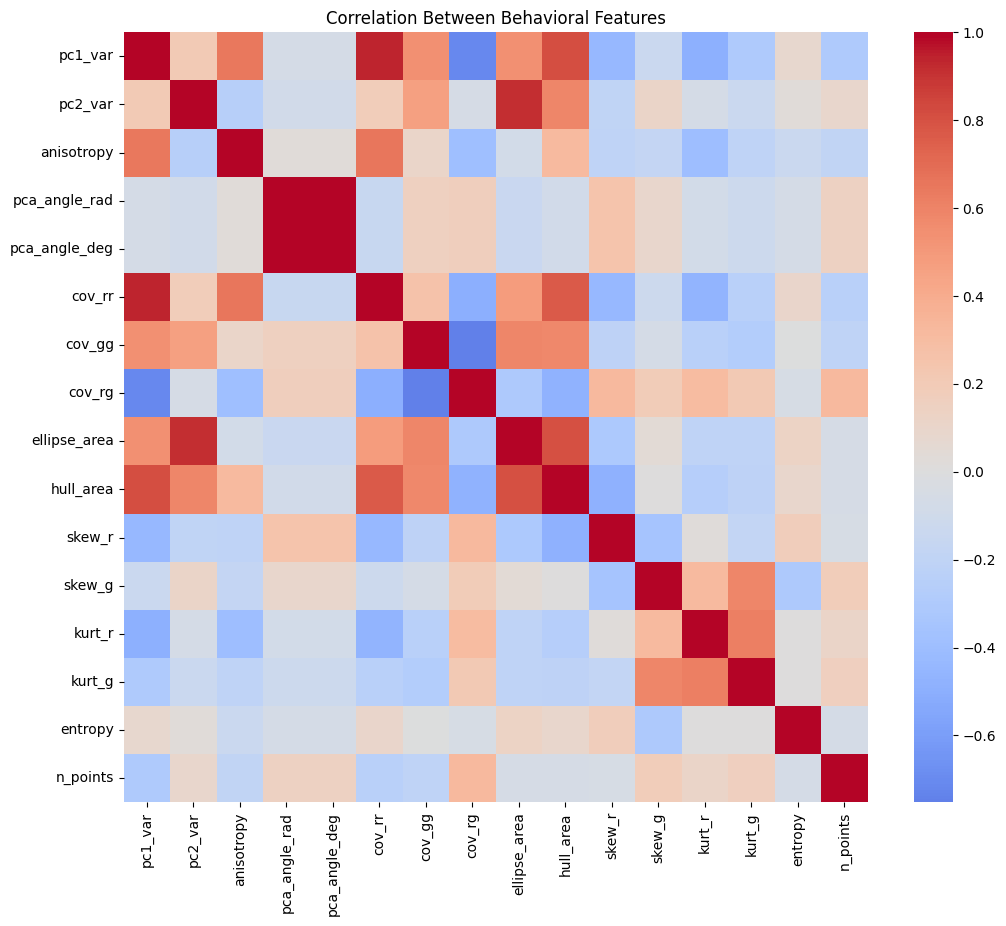

In [3]:
plot_feature_correlation(feat_df)


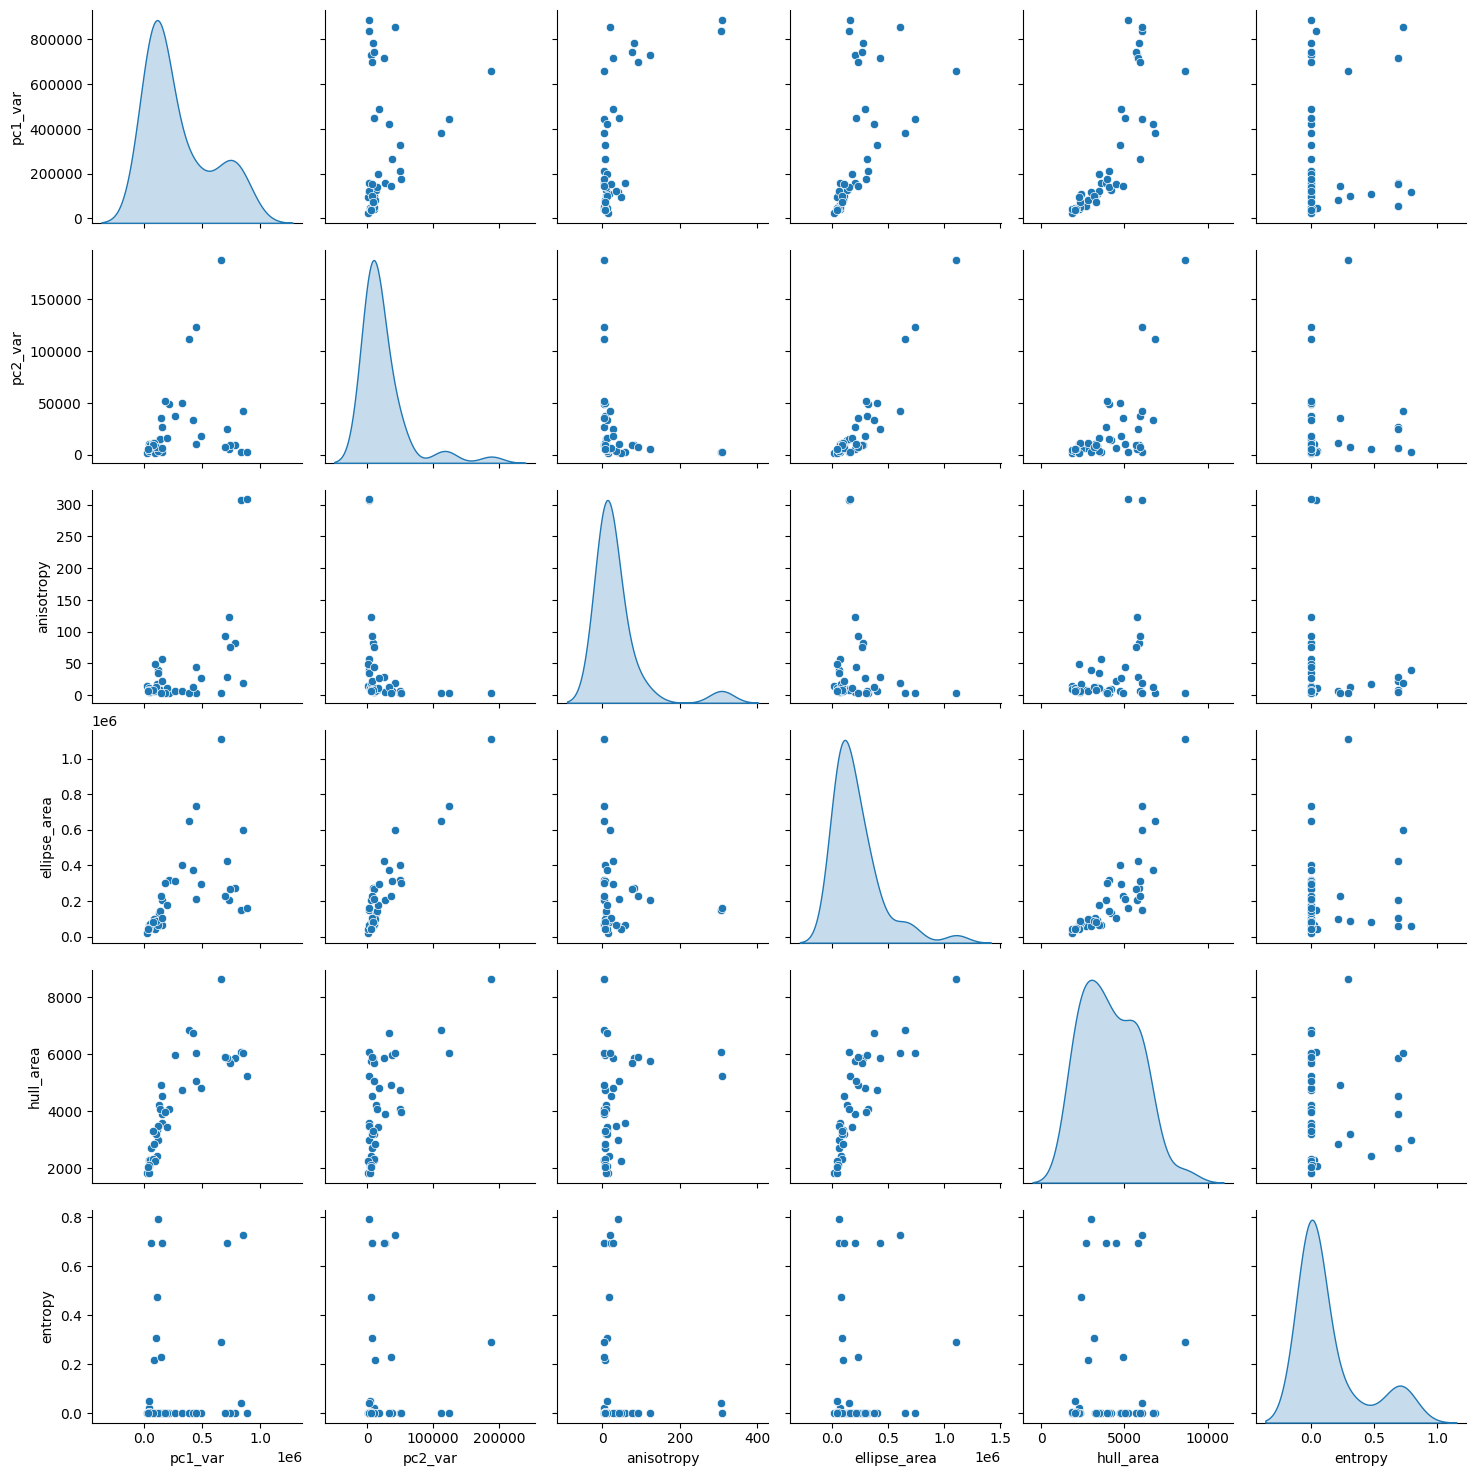

In [9]:
plot_feature_pairplot(feat_df)


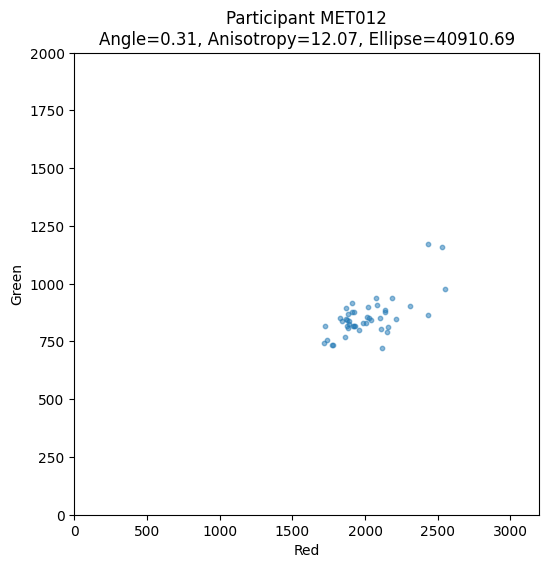

In [15]:
plot_participant_features(feat_df, df, pid="MET012")
